In [2]:
from pathlib import Path
import numpy as np

base_dir = Path("system_303")

A = np.genfromtxt(base_dir / "stiffness_beam_A.dat", delimiter=",")[3:, 3:]
b = np.genfromtxt(base_dir / "forcing_b.dat")[3:]
box = np.genfromtxt(base_dir / "B0_wide_bc.dat", delimiter=",")
x_star = np.genfromtxt(base_dir / "soln_x.dat")[3:]

ell0 = box[3:, 0]
u0 = box[3:, 1]


## Some tests for the alignment of the box

In [3]:
miscenterment = (ell0 + u0) / 2 - x_star
miscenterment.sort()
print(miscenterment)

widths = u0-ell0
widths.sort()
print(widths)


[-2.04898084e+00 -1.99710054e+00 -1.94522028e+00 -1.89334019e+00
 -1.84146055e+00 -1.78958194e+00 -1.73770526e+00 -1.68583188e+00
 -1.63396367e+00 -1.58210312e+00 -1.53025342e+00 -1.47841858e+00
 -1.42660344e+00 -1.37481383e+00 -1.32305664e+00 -1.27133989e+00
 -1.21967282e+00 -1.16806601e+00 -1.11653142e+00 -1.06508251e+00
 -1.01373433e+00 -9.62503586e-01 -9.11408737e-01 -8.60470091e-01
 -8.09709884e-01 -7.59152371e-01 -7.08823911e-01 -6.58753058e-01
 -6.08970649e-01 -5.59509886e-01 -5.10406433e-01 -4.61698493e-01
 -4.13426904e-01 -3.65635225e-01 -3.18369821e-01 -2.71679952e-01
 -2.25617864e-01 -1.80238872e-01 -1.35601452e-01 -9.17673261e-02
 -4.88015492e-02 -2.98158430e-02 -2.98158261e-02 -2.98157080e-02
 -2.98152861e-02 -2.98142231e-02 -2.98120463e-02 -2.98081479e-02
 -2.98017857e-02 -2.97920823e-02 -2.97780253e-02 -2.97584673e-02
 -2.97321257e-02 -2.96975836e-02 -2.96532882e-02 -2.95975517e-02
 -2.95285519e-02 -2.94443315e-02 -2.93427983e-02 -2.92217249e-02
 -2.90787485e-02 -2.89113

In [4]:
row_sums = np.sum(np.abs(A), axis=1)

row_idx = np.argmax(row_sums)
A_norm = row_sums[row_idx]

print("A infinity norm:", A_norm)
print("attained at row:", row_idx)
print("row:", A[row_idx])

A infinity norm: 3414573667555.5557
attained at row: 4
row: [ 0.00000000e+00 -8.22788836e+11 -6.17091627e+10  0.00000000e+00
  1.64557767e+12  0.00000000e+00  0.00000000e+00 -8.22788836e+11
  6.17091627e+10  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+

In [4]:
A[:, 0]

array([ 2.4856e+10,  0.0000e+00,  0.0000e+00, -1.2428e+10,  0.0000e+00,
        0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
        0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
        0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
        0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
        0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
        0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
        0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
        0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
        0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
        0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
        0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
        0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
        0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.00

## Implement the solver here

In [5]:
from dataclasses import dataclass

from scipy.linalg import qr
from scipy.optimize import linprog


@dataclass
class SPDSystem:
    A: np.ndarray
    b: np.ndarray
    x_star: np.ndarray
    ell0: np.ndarray
    u0: np.ndarray

    @property
    def n(self):
        return self.A.shape[0]


@dataclass
class ICGResult:
    ell: np.ndarray
    u: np.ndarray
    x_cg: np.ndarray
    residual: np.ndarray
    n_iters: int
    history: list | None


def _build_normalized_equalities(A, b, directions, tol=1e-12, rank_tol=1e-8):
    if not directions:
        return None, None, 0, 0

    A_eq = np.vstack([p @ A for p in directions]).astype(float, copy=False)
    b_eq = np.array([p @ b for p in directions], dtype=float)

    row_norms = np.linalg.norm(A_eq, axis=1)
    keep = row_norms > tol
    if not np.any(keep):
        return None, None, 0, 0

    A_eq = A_eq[keep]
    b_eq = b_eq[keep]
    row_norms = row_norms[keep]

    A_eq = A_eq / row_norms[:, None]
    b_eq = b_eq / row_norms

    _, r_factor, piv = qr(A_eq.T, mode="economic", pivoting=True)
    diag = np.abs(np.diag(r_factor))
    if diag.size == 0 or diag[0] <= tol:
        return None, None, int(A_eq.shape[0]), 0

    rank = int(np.sum(diag > rank_tol * diag[0]))
    selected = piv[:rank]
    return A_eq[selected], b_eq[selected], int(A_eq.shape[0]), rank


def _solve_with_highs(c, A_eq, b_eq, bounds, method, fallback_method=None, options=None):
    methods = [method]
    if fallback_method and fallback_method != method:
        methods.append(fallback_method)

    options = {"presolve": True} if options is None else dict(options)
    failures = []

    for current_method in methods:
        result = linprog(
            c,
            A_eq=A_eq,
            b_eq=b_eq,
            bounds=bounds,
            method=current_method,
            options=options,
        )
        if result.success:
            return result, current_method
        failures.append(f"{current_method}: {result.message}")

    raise RuntimeError("HiGHS failed. " + " | ".join(failures))


def _coordinate_bounds_from_constraints(
    A,
    b,
    ell0,
    u0,
    directions,
    method="highs-ipm",
    fallback_method="highs-ds",
    options=None,
    progress=True,
    print_every=25,
):
    n = A.shape[0]

    if not directions:
        if progress:
            print("[LP] no CG directions collected; returning the initial box.")
        return ell0.copy(), u0.copy()

    A_eq, b_eq, raw_count, reduced_count = _build_normalized_equalities(A, b, directions)
    if A_eq is None:
        if progress:
            print("[LP] all equality rows were numerically zero after normalization; returning the initial box.")
        return ell0.copy(), u0.copy()

    bounds = list(zip(ell0, u0))
    ell = np.empty(n, dtype=float)
    u = np.empty(n, dtype=float)

    if progress:
        print(
            f"[LP] solving {2 * n} coordinate LPs with {reduced_count} independent equalities "
            f"(from {raw_count} normalized rows) "
            f"using {method}" + (f" (fallback {fallback_method})" if fallback_method else "")
        )

    for i in range(n):
        c = np.zeros(n, dtype=float)
        c[i] = 1.0

        min_result, min_method = _solve_with_highs(
            c,
            A_eq,
            b_eq,
            bounds,
            method=method,
            fallback_method=fallback_method,
            options=options,
        )
        max_result, max_method = _solve_with_highs(
            -c,
            A_eq,
            b_eq,
            bounds,
            method=method,
            fallback_method=fallback_method,
            options=options,
        )

        ell[i] = min_result.x[i]
        u[i] = max_result.x[i]

        if progress and (i == 0 or (i + 1) % print_every == 0 or i + 1 == n):
            print(
                f"[LP] coordinate {i + 1:>3}/{n}: "
                f"[{ell[i]: .6e}, {u[i]: .6e}] "
                f"(min={min_method}, max={max_method})"
            )

    return ell, u


def interval_conjugate_gradient(
    system,
    ell0=None,
    u0=None,
    m=None,
    verbose=True,
    tol=1e-10,
    lp_method="highs-ipm",
    lp_fallback_method="highs-ds",
    lp_options=None,
    progress=True,
    lp_print_every=25,
):
    """
    Algorithm 3: run the usual CG iterations first, then solve the box LPs once at the end.

    The equality constraints p_j^T A x = p_j^T b are normalized row-wise before calling
    HiGHS. For the large 303x303 system, the interior-point variant is used first because
    the generic ``highs`` selection previously failed on some coordinate solves.
    """
    A = np.asarray(system.A, dtype=float)
    b = np.asarray(system.b, dtype=float)
    ell0 = np.array(system.ell0 if ell0 is None else ell0, dtype=float)
    u0 = np.array(system.u0 if u0 is None else u0, dtype=float)

    if A.shape[0] != A.shape[1]:
        raise ValueError("A must be square.")
    if b.shape != (A.shape[0],):
        raise ValueError("b must have shape (n,).")
    if ell0.shape != (A.shape[0],) or u0.shape != (A.shape[0],):
        raise ValueError("ell0 and u0 must have shape (n,).")
    if np.any(ell0 > u0):
        raise ValueError("Initial lower bounds must not exceed upper bounds.")

    n = system.n
    max_iter = n if m is None else int(m)
    if not 0 <= max_iter <= n:
        raise ValueError("m must satisfy 0 <= m <= n.")

    x = 0.5 * (ell0 + u0)
    r = b - A @ x
    p = r.copy()
    directions = []
    history = [] if verbose else None
    iters_done = 0

    if verbose:
        history.append(
            {
                "iteration": 0,
                "x": x.copy(),
                "residual": r.copy(),
                "direction": p.copy(),
                "alpha": None,
                "beta": None,
                "residual_norm": float(np.linalg.norm(r)),
                "constraint_count": 0,
            }
        )

    if progress:
        print(
            f"[ICG] start: n={n}, max_iter={max_iter}, tol={tol:.1e}, "
            f"lp_method={lp_method}"
        )

    for k in range(max_iter):
        residual_norm = float(np.linalg.norm(r))
        if progress:
            print(f"[ICG] iter {k:>3}: residual norm = {residual_norm:.6e}")

        if residual_norm <= tol:
            if progress:
                print(f"[ICG] converged before iteration {k}; skipping remaining CG steps.")
            break

        directions.append(p.copy())

        Ap = A @ p
        denom = float(p @ Ap)
        if abs(denom) <= tol:
            if progress:
                print(f"[ICG] stopping at iter {k}: p^T A p is too small ({denom:.6e}).")
            break

        rr = float(r @ r)
        alpha = rr / denom
        x_next = x + alpha * p
        r_next = r - alpha * Ap
        rr_next = float(r_next @ r_next)
        beta = 0.0 if rr <= tol else rr_next / rr
        p_next = r_next + beta * p

        iters_done = k + 1

        if verbose:
            history.append(
                {
                    "iteration": iters_done,
                    "x": x_next.copy(),
                    "residual": r_next.copy(),
                    "direction": p_next.copy(),
                    "alpha": float(alpha),
                    "beta": float(beta),
                    "residual_norm": float(np.sqrt(rr_next)),
                    "constraint_count": len(directions),
                    "p_used": p.copy(),
                }
            )

        x, r, p = x_next, r_next, p_next

    if progress:
        print(f"[ICG] CG phase finished after {iters_done} iterations.")
        print("[ICG] starting final box optimization.")

    ell, u = _coordinate_bounds_from_constraints(
        A=A,
        b=b,
        ell0=ell0,
        u0=u0,
        directions=directions,
        method=lp_method,
        fallback_method=lp_fallback_method,
        options=lp_options,
        progress=progress,
        print_every=lp_print_every,
    )

    if progress:
        widths = u - ell
        print(
            f"[ICG] done: residual norm = {np.linalg.norm(r):.6e}, "
            f"min width = {widths.min():.6e}, max width = {widths.max():.6e}"
        )

    return ICGResult(
        ell=ell,
        u=u,
        x_cg=x,
        residual=r,
        n_iters=iters_done,
        history=history,
    )


[ICG] start: n=300, max_iter=176, tol=1.0e-10, lp_method=highs-ipm
[ICG] iter   0: residual norm = 4.156639e+11
[ICG] iter   1: residual norm = 2.099942e+11
[ICG] iter   2: residual norm = 1.421172e+11
[ICG] iter   3: residual norm = 1.084259e+11
[ICG] iter   4: residual norm = 8.816224e+10
[ICG] iter   5: residual norm = 7.440029e+10
[ICG] iter   6: residual norm = 6.418826e+10
[ICG] iter   7: residual norm = 5.608198e+10
[ICG] iter   8: residual norm = 4.931813e+10
[ICG] iter   9: residual norm = 4.347773e+10
[ICG] iter  10: residual norm = 3.832758e+10
[ICG] iter  11: residual norm = 3.373689e+10
[ICG] iter  12: residual norm = 2.963035e+10
[ICG] iter  13: residual norm = 2.596097e+10
[ICG] iter  14: residual norm = 2.269476e+10
[ICG] iter  15: residual norm = 1.980262e+10
[ICG] iter  16: residual norm = 1.725660e+10
[ICG] iter  17: residual norm = 1.502866e+10
[ICG] iter  18: residual norm = 1.309062e+10
[ICG] iter  19: residual norm = 1.141475e+10
[ICG] iter  20: residual norm = 9

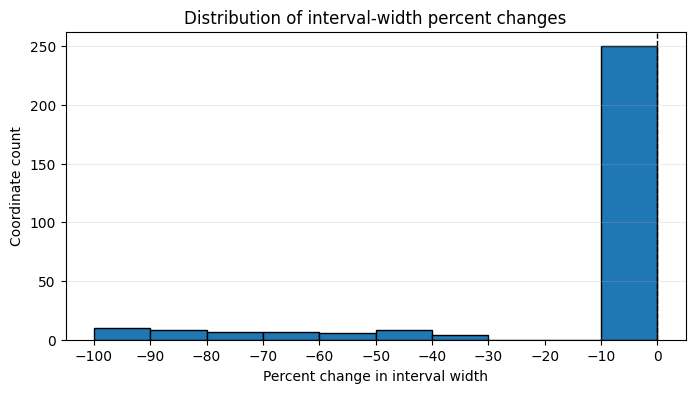

In [6]:
system303 = SPDSystem(
    A=A,
    b=b,
    x_star=x_star,
    ell0=ell0,
    u0=u0,
)

result303 = interval_conjugate_gradient(
    system303,
    m=176,
    verbose=True,
    tol=1e-10,
    lp_method="highs-ipm",
    lp_fallback_method="highs-ds",
    progress=True,
    lp_print_every=25,
)


def print_interval_contraction_report(ell0, u0, ell_m, u_m, max_rows=None, plot=True):
    initial_width = np.asarray(u0) - np.asarray(ell0)
    final_width = np.asarray(u_m) - np.asarray(ell_m)

    with np.errstate(divide="ignore", invalid="ignore"):
        pct_change = 100.0 * (final_width - initial_width) / initial_width

    n_rows = len(initial_width) if max_rows is None else min(max_rows, len(initial_width))
    header = (
        f"{'i':>4}  {'[ell0, u0]':>31}  {'w0':>12}  "
        f"{'[ell_m, u_m]':>31}  {'w_m':>12}  {'change':>10}"
    )
    print(header)
    print("-" * len(header))
    for i in range(n_rows):
        pct_label = "n/a" if not np.isfinite(pct_change[i]) else f"{pct_change[i]:+.2f}%"
        print(
            f"{i:4d}  "
            f"[{ell0[i]: .6e}, {u0[i]: .6e}]  {initial_width[i]: .6e}  "
            f"[{ell_m[i]: .6e}, {u_m[i]: .6e}]  {final_width[i]: .6e}  "
            f"{pct_label:>10}"
        )

    if max_rows is not None and n_rows < len(initial_width):
        print(f"... {len(initial_width) - n_rows} rows omitted")

    finite_pct_change = pct_change[np.isfinite(pct_change)]
    if plot and finite_pct_change.size:
        import matplotlib.pyplot as plt

        lo = 10.0 * np.floor(finite_pct_change.min() / 10.0)
        hi = 10.0 * np.ceil(finite_pct_change.max() / 10.0)
        if lo == hi:
            lo -= 10.0
            hi += 10.0
        bins = np.arange(lo, hi + 10.0, 10.0)

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(finite_pct_change, bins=bins, edgecolor="black")
        ax.axvline(0.0, color="black", linewidth=1, linestyle="--")
        ax.set_xlabel("Percent change in interval width")
        ax.set_ylabel("Coordinate count")
        ax.set_title("Distribution of interval-width percent changes")
        ax.set_xticks(bins)
        ax.grid(axis="y", alpha=0.25)
        plt.show()

    return pct_change


print("\nFinal residual norm:", np.linalg.norm(result303.residual))
print("Iterations completed:", result303.n_iters)
print("Minimum final width:", np.min(result303.u - result303.ell))
print("Maximum final width:", np.max(result303.u - result303.ell))
print(
    "x_star inside final box:",
    bool(np.all(result303.ell <= x_star + 1e-8) and np.all(x_star <= result303.u + 1e-8)),
)

width_pct_change = print_interval_contraction_report(
    ell0,
    u0,
    result303.ell,
    result303.u,
)


## Inspecting the Matrix and Troubleshooting

In [7]:
eigvals = np.linalg.eigvalsh(A)
print("lambda_min:", eigvals[0])
print("lambda_max:", eigvals[-1])
print("condition number:", eigvals[-1] / eigvals[0])
print("symmetry error:", np.linalg.norm(A - A.T))
print("x_star residual:", np.linalg.norm(b - A @ x_star))

lambda_min: 700.0822039403139
lambda_max: 3287990089379.0034
condition number: 4696577160.329194
symmetry error: 0.0
x_star residual: 0.0023467912085262553
